#**Movie Reccomendation System**

In [1]:
import numpy as np
import pandas as pd
import difflib # for Fuzzy name matching. (string-matching technique that identifies similar and non-identical names in datasets)
from sklearn.feature_extraction.text import TfidfVectorizer # concerting text into numeric vectors.
from sklearn.metrics.pairwise import cosine_similarity # computing similarity

In [2]:
movies_data = pd.read_csv("/content/movies.csv")

In [3]:
movies_data.head()

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


In [4]:
movies_data.shape

(4803, 24)

In [5]:
# selecting the relevant features for recommendation

selected_features = ['genres','keywords','tagline','cast','director']
print(selected_features)

['genres', 'keywords', 'tagline', 'cast', 'director']


In [6]:
# replacing the null valuess with null string

for feature in selected_features:
  movies_data[feature] = movies_data[feature].fillna('')

In [7]:
# combining all the 5 selected features

combined_features = movies_data['genres']+' '+movies_data['keywords']+' '+movies_data['tagline']+' '+movies_data['cast']+' '+movies_data['director']

In [8]:
print(combined_features)

0       Action Adventure Fantasy Science Fiction cultu...
1       Adventure Fantasy Action ocean drug abuse exot...
2       Action Adventure Crime spy based on novel secr...
3       Action Crime Drama Thriller dc comics crime fi...
4       Action Adventure Science Fiction based on nove...
                              ...                        
4798    Action Crime Thriller united states\u2013mexic...
4799    Comedy Romance  A newlywed couple's honeymoon ...
4800    Comedy Drama Romance TV Movie date love at fir...
4801      A New Yorker in Shanghai Daniel Henney Eliza...
4802    Documentary obsession camcorder crush dream gi...
Length: 4803, dtype: object


#**TF-IDF = Term Frequency x Inverse Document Frequency**

1️⃣ Term Frequency (TF)

Measures:

How important is a word inside a document?

Formula:

TF(word) = Count of word in document / Total words in documents

Example:

Document → "action action hero"

TF:

action = 2/3

hero = 1/3

✔ Words repeated more → higher TF

2️⃣ Inverse Document Frequency (IDF)

Measures:

How rare is a word across ALL documents?

Formula:

IDF(word) = log(Total Documents / Documents containing word)

Example:

word = action, appears in many docs, meaning that it is less informative.

word = avatar, appears in fewer docs, meaning that it is more informative

✔ Rare words → higher IDF

✔ Common words → lower IDF

**Final TF-IDF Score**

TF-IDF = TF x IDF

Meaning:

Frequent in document

Rarer across dataset

HIgh importance.

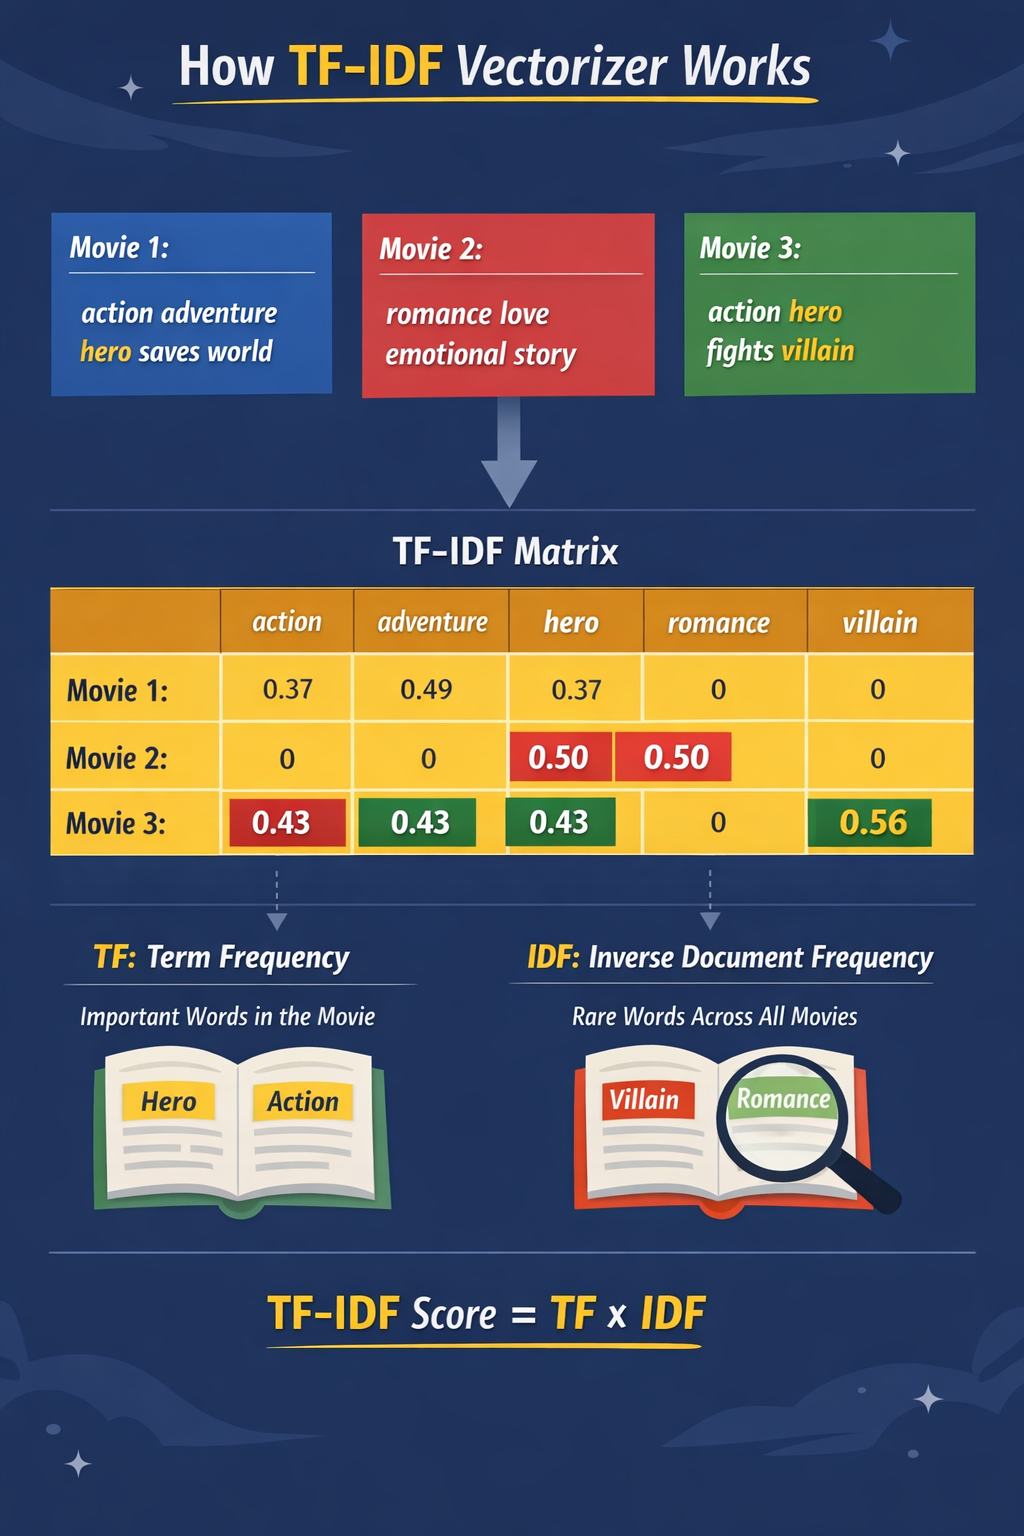

DIY Task - Why tfidf works well with cosine similarity? & What are the limitations of tfidf.

In [9]:
# converting the text data to feature vectors

vectorizer = TfidfVectorizer()

In [10]:
feature_vectors = vectorizer.fit_transform(combined_features)

In [11]:
print(feature_vectors)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 124266 stored elements and shape (4803, 17318)>
  Coords	Values
  (0, 201)	0.07860022416510505
  (0, 274)	0.09021200873707368
  (0, 5274)	0.11108562744414445
  (0, 13599)	0.1036413987316636
  (0, 5437)	0.1036413987316636
  (0, 3678)	0.21392179219912877
  (0, 3065)	0.22208377802661425
  (0, 5836)	0.1646750903586285
  (0, 14378)	0.33962752210959823
  (0, 16587)	0.12549432354918996
  (0, 3225)	0.24960162956997736
  (0, 14271)	0.21392179219912877
  (0, 4945)	0.24025852494110758
  (0, 15261)	0.07095833561276566
  (0, 16998)	0.1282126322850579
  (0, 11192)	0.09049319826481456
  (0, 11503)	0.27211310056983656
  (0, 13349)	0.15021264094167086
  (0, 17007)	0.23643326319898797
  (0, 17290)	0.20197912553916567
  (0, 13319)	0.2177470539412484
  (0, 14064)	0.20596090415084142
  (0, 16668)	0.19843263965100372
  (0, 14608)	0.15150672398763912
  (0, 8756)	0.22709015857011816
  :	:
  (4801, 403)	0.17727585190343229
  (4801, 4835)	0.247137650

Cosine Similarity

In [12]:
# getting the similarity scores using cosine similarity

similarity = cosine_similarity(feature_vectors)

In [13]:
print(similarity)

[[1.         0.07219487 0.037733   ... 0.         0.         0.        ]
 [0.07219487 1.         0.03281499 ... 0.03575545 0.         0.        ]
 [0.037733   0.03281499 1.         ... 0.         0.05389661 0.        ]
 ...
 [0.         0.03575545 0.         ... 1.         0.         0.02651502]
 [0.         0.         0.05389661 ... 0.         1.         0.        ]
 [0.         0.         0.         ... 0.02651502 0.         1.        ]]


In [14]:
print(similarity.shape)

(4803, 4803)


Getting the movie name from the user

In [15]:
# getting the movie name from the user

movie_name = input(' Enter your favourite movie name : ')

 Enter your favourite movie name : James Bond


In [16]:
# creating a list with all the movie names given in the dataset

list_of_all_titles = movies_data['title'].tolist()
print(list_of_all_titles)

['Avatar', "Pirates of the Caribbean: At World's End", 'Spectre', 'The Dark Knight Rises', 'John Carter', 'Spider-Man 3', 'Tangled', 'Avengers: Age of Ultron', 'Harry Potter and the Half-Blood Prince', 'Batman v Superman: Dawn of Justice', 'Superman Returns', 'Quantum of Solace', "Pirates of the Caribbean: Dead Man's Chest", 'The Lone Ranger', 'Man of Steel', 'The Chronicles of Narnia: Prince Caspian', 'The Avengers', 'Pirates of the Caribbean: On Stranger Tides', 'Men in Black 3', 'The Hobbit: The Battle of the Five Armies', 'The Amazing Spider-Man', 'Robin Hood', 'The Hobbit: The Desolation of Smaug', 'The Golden Compass', 'King Kong', 'Titanic', 'Captain America: Civil War', 'Battleship', 'Jurassic World', 'Skyfall', 'Spider-Man 2', 'Iron Man 3', 'Alice in Wonderland', 'X-Men: The Last Stand', 'Monsters University', 'Transformers: Revenge of the Fallen', 'Transformers: Age of Extinction', 'Oz: The Great and Powerful', 'The Amazing Spider-Man 2', 'TRON: Legacy', 'Cars 2', 'Green Lant

In [17]:
# finding the close match for the movie name given by the user

find_close_match = difflib.get_close_matches(movie_name, list_of_all_titles)
print(find_close_match)

['Jason Bourne', 'Jackie Brown', 'The Beyond']


In [18]:
close_match = find_close_match[0]
print(close_match)

Jason Bourne


In [19]:
# finding the index of the movie with title

index_of_the_movie = movies_data[movies_data.title == close_match]['index'].values[0]
print(index_of_the_movie)

218


In [20]:
# getting a list of similar movies

similarity_score = list(enumerate(similarity[index_of_the_movie]))
print(similarity_score)

[(0, np.float64(0.007257784423577761)), (1, np.float64(0.00633460921334688)), (2, np.float64(0.007425642219938728)), (3, np.float64(0.015663791368356352)), (4, np.float64(0.007067249524999125)), (5, np.float64(0.05986890581988854)), (6, np.float64(0.0)), (7, np.float64(0.0073257919988893505)), (8, np.float64(0.0)), (9, np.float64(0.007157301596137536)), (10, np.float64(0.0081633365977961)), (11, np.float64(0.012462156400728137)), (12, np.float64(0.0074105684916571666)), (13, np.float64(0.006690713875591062)), (14, np.float64(0.020427896067951826)), (15, np.float64(0.0)), (16, np.float64(0.006946408058157563)), (17, np.float64(0.007089069063736587)), (18, np.float64(0.09210226732423238)), (19, np.float64(0.006293943129589667)), (20, np.float64(0.007227661485172998)), (21, np.float64(0.006091060840009604)), (22, np.float64(0.0)), (23, np.float64(0.0)), (24, np.float64(0.006847024136141945)), (25, np.float64(0.006816984082663962)), (26, np.float64(0.007560854439957565)), (27, np.float64(0

In [21]:
len(similarity_score)

4803

In [22]:
# sorting the movies based on their similarity score

sorted_similar_movies = sorted(similarity_score, key = lambda x:x[1], reverse = True)
print(sorted_similar_movies)

[(218, np.float64(1.0000000000000002)), (386, np.float64(0.3636418500365508)), (180, np.float64(0.32183149997798444)), (2495, np.float64(0.18489102806616242)), (2503, np.float64(0.1820133740368921)), (2623, np.float64(0.16685298175926364)), (3793, np.float64(0.15608980706630843)), (312, np.float64(0.14776174754842838)), (3080, np.float64(0.14077227092194958)), (2056, np.float64(0.1404590187875681)), (2976, np.float64(0.13188751065195267)), (388, np.float64(0.13096425340552498)), (575, np.float64(0.12929111507126925)), (3075, np.float64(0.1282223895632993)), (2909, np.float64(0.12459414694534757)), (2743, np.float64(0.12422387331833193)), (1820, np.float64(0.12394831950083599)), (2215, np.float64(0.12362985648494826)), (342, np.float64(0.1204223603494969)), (1735, np.float64(0.11956060163749006)), (531, np.float64(0.11618793398555219)), (694, np.float64(0.11517318390948124)), (2774, np.float64(0.11503954707393411)), (1139, np.float64(0.11318193134620383)), (2752, np.float64(0.1116159615

In [23]:
# print the name of similar movies based on the index

print('Movies suggested for you : \n')

i = 1

for movie in sorted_similar_movies:
  index = movie[0]
  title_from_index = movies_data[movies_data.index==index]['title'].values[0]
  if (i<30):
    print(i, '.',title_from_index)
    i+=1

Movies suggested for you : 

1 . Jason Bourne
2 . The Bourne Supremacy
3 . The Bourne Ultimatum
4 . Trance
5 . The Homesman
6 . The Three Burials of Melquiades Estrada
7 . The Velocity of Gary
8 . Green Zone
9 . Bamboozled
10 . Before I Go to Sleep
11 . Misconduct
12 . Ocean's Eleven
13 . Vanilla Sky
14 . Crash
15 . The Cry of the Owl
16 . The Butterfly Effect
17 . The Fifth Estate
18 . Burnt
19 . Men in Black
20 . Ghosts of Mars
21 . The Man from U.N.C.L.E.
22 . The Bourne Identity
23 . Faithful
24 . The Warrior's Way
25 . Ex Machina
26 . The Messenger: The Story of Joan of Arc
27 . Invictus
28 . In the Valley of Elah
29 . Down Terrace


Movie Recommendation Sytem

In [24]:
movie_name = input(' Enter your favourite movie name : ')

list_of_all_titles = movies_data['title'].tolist()

find_close_match = difflib.get_close_matches(movie_name, list_of_all_titles)

close_match = find_close_match[0]

index_of_the_movie = movies_data[movies_data.title == close_match]['index'].values[0]

similarity_score = list(enumerate(similarity[index_of_the_movie]))

sorted_similar_movies = sorted(similarity_score, key = lambda x:x[1], reverse = True)

print('Movies suggested for you : \n')

i = 1

for movie in sorted_similar_movies:
  index = movie[0]
  title_from_index = movies_data[movies_data.index==index]['title'].values[0]
  if (i<30):
    print(i, '.',title_from_index)
    i+=1

 Enter your favourite movie name : James Bond
Movies suggested for you : 

1 . Jason Bourne
2 . The Bourne Supremacy
3 . The Bourne Ultimatum
4 . Trance
5 . The Homesman
6 . The Three Burials of Melquiades Estrada
7 . The Velocity of Gary
8 . Green Zone
9 . Bamboozled
10 . Before I Go to Sleep
11 . Misconduct
12 . Ocean's Eleven
13 . Vanilla Sky
14 . Crash
15 . The Cry of the Owl
16 . The Butterfly Effect
17 . The Fifth Estate
18 . Burnt
19 . Men in Black
20 . Ghosts of Mars
21 . The Man from U.N.C.L.E.
22 . The Bourne Identity
23 . Faithful
24 . The Warrior's Way
25 . Ex Machina
26 . The Messenger: The Story of Joan of Arc
27 . Invictus
28 . In the Valley of Elah
29 . Down Terrace
